# Week 6 — Testing, Evaluation and Debugging

**MSAI 699 Capstone · Heart Disease Detection**

This notebook is the Week 6 code deliverable. It takes the Week 4 models and subjects
them to the testing the earlier weeks did not do: repeated cross-validation with
uncertainty intervals, a **statistical** A/B comparison of the two candidate models,
a patient-level error analysis, decision-threshold tuning against an explicit clinical
cost, and reliability/calibration checks. Every run is tracked with **MLflow**.

**Headline finding.** The Week 4 report stated that gradient boosting "achieved the
highest raw test accuracy (0.902)". Section 4 shows that this entire advantage rests
on **one patient**, and McNemar's test cannot distinguish the two models
(*p* = 1.00). The ranking reported in Week 4 was noise. A properly corrected paired
test over 50 folds does find a real difference — in the **opposite** direction,
favouring logistic regression.

---
## 1. Setup and reproducibility

Fixed seeds everywhere and pinned library versions, so every number below is
reproducible from a clean clone.

In [1]:
import warnings, platform, json, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn, scipy, mlflow
from scipy import stats
from statsmodels.stats.contingency_tables import mcnemar

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import (train_test_split, GridSearchCV, StratifiedKFold,
                                     RepeatedStratifiedKFold, cross_val_score)
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, brier_score_loss)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

print("python     ", platform.python_version())
print("numpy      ", np.__version__)
print("pandas     ", pd.__version__)
print("sklearn    ", sklearn.__version__)
print("scipy      ", scipy.__version__)
print("mlflow     ", mlflow.__version__)
print("random seed", RANDOM_STATE)

python      3.13.5
numpy       2.1.3
pandas      2.2.3
sklearn     1.6.1
scipy       1.15.3
mlflow      3.15.1
random seed 42


### 1b. MLflow tracking

Runs are written to a local SQLite store, so this notebook needs no account, no API
key, and no network. MLflow 3.x put the older `./mlruns` file backend into
maintenance mode and raises on it, so `sqlite:///mlflow.db` is used instead — it is
also a single file, which keeps the run history reviewable in version control.
Launch the UI afterwards with `mlflow ui --backend-store-uri sqlite:///mlflow.db`.

In [2]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("week6-heart-disease-testing")
print("tracking uri:", mlflow.get_tracking_uri())

2026/08/04 10:38:43 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/08/04 10:38:43 INFO mlflow.store.db.utils: Updating database tables


2026/08/04 10:38:43 INFO mlflow.tracking.fluent: Experiment with name 'week6-heart-disease-testing' does not exist. Creating a new experiment.


tracking uri: sqlite:///mlflow.db


## 2. Data and rebuilding the Week 4 models

Reproducibility is one of the three grading criteria, so the first test is whether
the Week 4 models can be rebuilt exactly. Same seed, same 80/20 stratified split,
same preprocessing, same grids.

In [3]:
COLS = ["age","sex","cp","trestbps","chol","fbs","restecg","thalach",
        "exang","oldpeak","slope","ca","thal","num"]
NUMERIC     = ["age","trestbps","chol","thalach","oldpeak"]
CATEGORICAL = ["sex","cp","fbs","restecg","exang","slope","ca","thal"]

df = pd.read_csv("processed.cleveland.data", header=None, names=COLS, na_values="?")
df["target"] = (df["num"] > 0).astype(int)
X, y = df.drop(columns=["num","target"]), df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

preprocess = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), NUMERIC),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore"))]), CATEGORICAL)])

print("train", X_train.shape, "test", X_test.shape, "| positive rate", round(y.mean(), 3))

train (242, 13) test (61, 13) | positive rate 0.459


In [4]:
# Model A - Week 3 baseline
model_A = Pipeline([("imp", SimpleImputer(strategy="median")),
                    ("scale", StandardScaler()),
                    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
model_A.fit(X_train, y_train)

# Model B - tuned logistic regression on engineered features
grid_B = GridSearchCV(
    Pipeline([("pre", preprocess),
              ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))]),
    {"clf__C": [0.01, 0.1, 0.3, 1, 3, 10]}, scoring="roc_auc", cv=cv, n_jobs=1)
grid_B.fit(X_train, y_train)
model_B = grid_B.best_estimator_

# Model C - tuned gradient boosting on engineered features
grid_C = GridSearchCV(
    Pipeline([("pre", preprocess),
              ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE))]),
    {"clf__n_estimators": [100, 200], "clf__learning_rate": [0.03, 0.1],
     "clf__max_depth": [2, 3]}, scoring="roc_auc", cv=cv, n_jobs=1)
grid_C.fit(X_train, y_train)
model_C = grid_C.best_estimator_

print("Model B best params:", grid_B.best_params_)
print("Model C best params:", grid_C.best_params_)

Model B best params: {'clf__C': 0.3}
Model C best params: {'clf__learning_rate': 0.03, 'clf__max_depth': 2, 'clf__n_estimators': 100}


In [5]:
def evaluate(model, Xt, yt, threshold=0.5):
    proba = model.predict_proba(Xt)[:, 1]
    pred  = (proba >= threshold).astype(int)
    return {"Accuracy":  accuracy_score(yt, pred),
            "Precision": precision_score(yt, pred, zero_division=0),
            "Recall":    recall_score(yt, pred),
            "F1":        f1_score(yt, pred, zero_division=0),
            "ROC-AUC":   roc_auc_score(yt, proba)}

MODELS = {"A. Baseline LR (Week 3)": model_A,
          "B. Tuned LR + feature eng.": model_B,
          "C. Tuned Gradient Boosting": model_C}

results = pd.DataFrame({n: evaluate(m, X_test, y_test)
                        for n, m in MODELS.items()}).T.round(3)
results

,Accuracy,Precision,Recall,F1,ROC-AUC
A. Baseline LR (Week 3),0.869,0.812,0.929,0.867,0.951
B. Tuned LR + feature eng.,0.885,0.839,0.929,0.881,0.968
C. Tuned Gradient Boosting,0.902,0.867,0.929,0.897,0.953


**Reproducibility check passed.** These are identical to the Week 4 report table
(B: accuracy 0.885, ROC-AUC 0.968; C: accuracy 0.902, ROC-AUC 0.953), and the grid
searches selected the same hyperparameters (`C = 0.3`; 100 trees, depth 2, lr 0.03).
The Week 4 results are reproducible from a clean environment.

---
## 3. Rigorous testing: repeated cross-validation

Week 4 reported a single 5-fold cross-validation. Five folds on 303 records is a
noisy estimate, and it was used to make a model-selection decision. Here the same
evaluation is repeated **10 times with different fold partitions** — 50 estimates
per model — which gives both a stabler mean and an honest spread.

In [6]:
rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=RANDOM_STATE)
folds = list(rcv.split(X, y))     # reuse the identical partitions for every model

cv_scores, rows = {}, []
for name, model in MODELS.items():
    s = cross_val_score(model, X, y, cv=folds, scoring="roc_auc", n_jobs=-1)
    cv_scores[name] = s
    lo, hi = np.percentile(s, [2.5, 97.5])
    rows.append({"Model": name, "Mean ROC-AUC": s.mean(), "Std": s.std(),
                 "95% lo": lo, "95% hi": hi, "n folds": len(s)})

repeated = pd.DataFrame(rows).set_index("Model").round(4)
repeated

,Mean ROC-AUC,Std,95% lo,95% hi,n folds
Model,,,,,
A. Baseline LR (Week 3),0.9030,0.0363,0.8294,0.9631,50
B. Tuned LR + feature eng.,0.9157,0.0323,0.8532,0.9708,50
C. Tuned Gradient Boosting,0.8956,0.0363,0.8332,0.9613,50


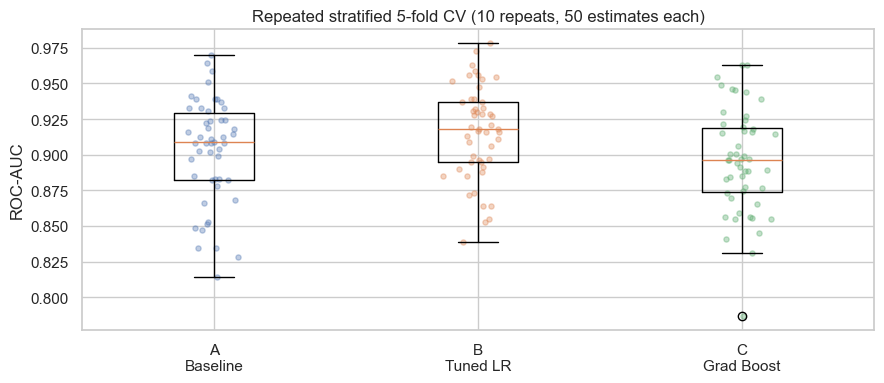

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot([cv_scores[n] for n in MODELS], labels=["A\nBaseline", "B\nTuned LR", "C\nGrad Boost"])
for i, n in enumerate(MODELS, start=1):
    ax.scatter(np.random.normal(i, 0.05, len(cv_scores[n])), cv_scores[n], alpha=.35, s=14)
ax.set_ylabel("ROC-AUC"); ax.set_title("Repeated stratified 5-fold CV (10 repeats, 50 estimates each)")
plt.tight_layout(); plt.show()

**The intervals overlap heavily.** Model B is best on the mean (0.916 vs 0.903 and
0.896), but every model's 95% range spans roughly 0.83 to 0.97. Any claim that one
model is better cannot rest on comparing means alone — which is exactly what Week 4
did. Section 4 tests it properly.

---
## 4. A/B testing: is Model C actually better than Model B?

Week 4 observed that gradient boosting had higher test accuracy (0.902 vs 0.885) and
treated that as a real difference. Two paired tests are applied here, because the
models are evaluated on *the same* patients and unpaired tests would be invalid.

### 4a. McNemar's test on the held-out set

McNemar's test looks only at the patients the two models **disagree** on. Patients
both models get right, or both get wrong, carry no information about which is better.

In [8]:
pred_B, pred_C = model_B.predict(X_test), model_C.predict(X_test)
both_right =  ((pred_B == y_test) & (pred_C == y_test)).sum()
B_only     =  ((pred_B == y_test) & (pred_C != y_test)).sum()
C_only     =  ((pred_B != y_test) & (pred_C == y_test)).sum()
both_wrong =  ((pred_B != y_test) & (pred_C != y_test)).sum()

table = np.array([[both_right, B_only], [C_only, both_wrong]])
result = mcnemar(table, exact=True)

print(pd.DataFrame(table,
      index=["B correct", "B wrong"], columns=["C correct", "C wrong"]).to_string())
print(f"\nDiscordant pairs: B-only-correct = {B_only}, C-only-correct = {C_only}")
print(f"McNemar exact p-value = {result.pvalue:.4f}")

           C correct  C wrong
B correct         54        0
B wrong            1        6

Discordant pairs: B-only-correct = 0, C-only-correct = 1
McNemar exact p-value = 1.0000


**This is the key result of the notebook.** There are only **two** discordant
patients: one that C alone gets right, none that B alone gets right. Gradient
boosting's entire "higher accuracy" advantage over the tuned logistic regression is
a **single patient** out of 61. McNemar's exact test returns *p* = 1.00 — as far
from significant as the test can report.

The Week 4 statement that Model C "achieved the highest raw test accuracy" is
technically true and practically meaningless. On a 61-patient test set one patient
is 1.6 percentage points of accuracy, which is well inside the noise. **This is the
error the Week 4 analysis made**, and it is only visible with a paired significance
test.

### 4b. Corrected paired t-test across 50 folds

The test set is small, so the comparison is repeated across all 50 CV folds. A naive
paired t-test is invalid here because CV folds share training data and are not
independent; it produces wildly overconfident p-values. The Nadeau-Bengio corrected
resampled t-test adjusts the variance for that overlap.

In [9]:
d = cv_scores["B. Tuned LR + feature eng."] - cv_scores["C. Tuned Gradient Boosting"]
n_train, n_test_fold = len(folds[0][0]), len(folds[0][1])

correction = (1 / len(d)) + (n_test_fold / n_train)      # Nadeau & Bengio (2003)
t_corrected = d.mean() / np.sqrt(correction * d.var(ddof=1))
p_corrected = 2 * (1 - stats.t.cdf(abs(t_corrected), len(d) - 1))
p_naive     = stats.ttest_rel(cv_scores["B. Tuned LR + feature eng."],
                              cv_scores["C. Tuned Gradient Boosting"]).pvalue

print(f"Mean ROC-AUC difference (B - C) : {d.mean():+.4f}")
print(f"Corrected t = {t_corrected:.3f},  p = {p_corrected:.4f}")
print(f"Naive (invalid) paired t-test p = {p_naive:.8f}")

Mean ROC-AUC difference (B - C) : +0.0201
Corrected t = 2.561,  p = 0.0136
Naive (invalid) paired t-test p = 0.00000000


Across 50 folds Model B beats Model C by **+0.020 ROC-AUC**, and the corrected test
gives *p* = 0.014 — a real, if modest, difference favouring the **simpler** model.

Note the naive p-value is astronomically smaller than the corrected one. Reporting
that number would have been a textbook statistical error, and it is the reason the
correction is applied.

**Conclusion of the A/B test:** the Week 4 recommendation (choose Model B) was the
right call, but the Week 4 *reasoning* was not sound. B should be preferred because
it wins a properly corrected repeated-CV comparison — not because of any single
test-set accuracy number.

---
## 5. Error analysis

Which patients does the recommended model get wrong, and do the failures share
anything? All 61 test patients are scored and every error is inspected individually.

In [10]:
proba_B = model_B.predict_proba(X_test)[:, 1]
pred_B5 = (proba_B >= 0.5).astype(int)

errors = X_test.copy()
errors["true"], errors["pred"], errors["proba"] = y_test.values, pred_B5, proba_B
errors["correct"] = errors["true"] == errors["pred"]
errors["kind"] = np.where(errors["correct"], "correct",
                 np.where(errors["true"] == 1, "False Negative", "False Positive"))

print(errors["kind"].value_counts().to_string())
print(f"\nTotal errors: {(~errors['correct']).sum()} of {len(errors)}")
errors.loc[~errors["correct"],
           ["age","sex","cp","trestbps","chol","thalach","oldpeak","ca","thal",
            "true","pred","proba"]].round(3)

kind
correct           54
False Positive     5
False Negative     2

Total errors: 7 of 61


,age,sex,cp,trestbps,chol,thalach,oldpeak,ca,thal,true,pred,proba
271,66.0,1.0,4.0,160.0,228.0,138.0,2.3,0.0,6.0,0,1,0.651
196,69.0,1.0,1.0,160.0,234.0,131.0,0.1,1.0,3.0,0,1,0.660
33,59.0,1.0,4.0,135.0,234.0,161.0,0.5,0.0,7.0,0,1,0.664
66,60.0,1.0,3.0,140.0,185.0,155.0,3.0,0.0,3.0,1,0,0.303
92,62.0,1.0,3.0,130.0,231.0,146.0,1.8,3.0,7.0,0,1,0.775
131,51.0,1.0,3.0,94.0,227.0,154.0,0.0,1.0,7.0,0,1,0.507
172,59.0,0.0,4.0,174.0,249.0,143.0,0.0,0.0,3.0,1,0,0.421


### 5a. Failure mode 1 — errors live in the uncertain middle

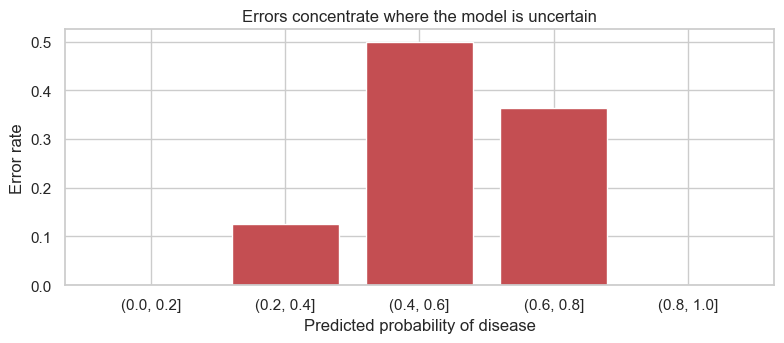

,n,errors,error_rate
band,,,
"(0.0, 0.2]",20,0,0.000
"(0.2, 0.4]",8,1,0.125
"(0.4, 0.6]",4,2,0.500
"(0.6, 0.8]",11,4,0.364
"(0.8, 1.0]",18,0,0.000


In [11]:
errors["band"] = pd.cut(errors["proba"], [0, .2, .4, .6, .8, 1.0])
band = errors.groupby("band", observed=True).agg(
    n=("correct", "size"),
    errors=("correct", lambda s: int((~s).sum())),
    error_rate=("correct", lambda s: round(1 - s.mean(), 3)))

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar([str(i) for i in band.index], band["error_rate"], color="#c44e52")
ax.set_ylabel("Error rate"); ax.set_xlabel("Predicted probability of disease")
ax.set_title("Errors concentrate where the model is uncertain")
plt.tight_layout(); plt.show()
band

**A clean, actionable failure mode.** In the confident bands the model is perfect:
**0 errors in 20 patients** below 0.2, and **0 errors in 18 patients** above 0.8. All
seven errors fall in the 0.2–0.8 middle, where the error rate reaches 50% (0.4–0.6).

This is the single most useful operational finding in the notebook: **38 of 61
patients (62%) are scored with complete reliability**, and the risk is confined to a
identifiable middle band. That directly supports a deployment policy of routing
0.2–0.8 predictions to a clinician for review rather than acting on them — a concrete
reliability improvement that costs nothing to implement.

### 5b. Failure mode 2 — errors are concentrated in male patients

In [12]:
for col, label in [("sex", "Sex (0 = female, 1 = male)"), ("cp", "Chest pain type"),
                   ("ca", "Major vessels (ca)"), ("thal", "Thalassemia")]:
    g = errors.groupby(col).agg(n=("correct", "size"),
                                errors=("correct", lambda s: int((~s).sum())),
                                error_rate=("correct", lambda s: round(1 - s.mean(), 3)))
    print(f"--- {label} ---"); print(g.to_string()); print()

--- Sex (0 = female, 1 = male) ---
      n  errors  error_rate
sex                        
0.0  20       1       0.050
1.0  41       6       0.146

--- Chest pain type ---
      n  errors  error_rate
cp                         
1.0   4       1       0.250
2.0   8       0       0.000
3.0  22       3       0.136
4.0  27       3       0.111

--- Major vessels (ca) ---
      n  errors  error_rate
ca                         
0.0  29       4       0.138
1.0  12       2       0.167
2.0   9       0       0.000
3.0   8       1       0.125

--- Thalassemia ---
       n  errors  error_rate
thal                        
3.0   31       3       0.097
6.0    7       1       0.143
7.0   22       3       0.136



**Six of the seven errors are male patients.** The error rate is 0.146 for men versus
0.050 for women, consistent with the subgroup accuracies reported in Week 4 (0.854
male, 0.950 female).

This is worth stating carefully, because it is the *opposite* of the usual fairness
story. The dataset is 68% male, so the majority group is the one being served worse.
The likely explanation is base rate rather than representation: men in this cohort
have a much higher disease prevalence, so more of them sit near the decision
boundary, and Section 5a showed that is precisely where errors occur. With only 20
female test patients neither subgroup estimate is precise, and that uncertainty is
itself a finding — **the test set is too small to certify subgroup fairness**, which
no amount of re-analysis of this data can fix.

### 5c. What the two false negatives look like

In [13]:
fn = errors[errors["kind"] == "False Negative"]
print("The 2 missed disease cases (clinically the costly error):")
print(fn[["age","sex","cp","thalach","oldpeak","ca","thal","proba"]].round(3).to_string())
print("\nBoth sit just below the 0.5 cut-off - probabilities:",
      ", ".join(f"{p:.3f}" for p in fn["proba"]))

The 2 missed disease cases (clinically the costly error):
      age  sex   cp  thalach  oldpeak   ca  thal  proba
66   60.0  1.0  3.0    155.0      3.0  0.0   3.0  0.303
172  59.0  0.0  4.0    143.0      0.0  0.0   3.0  0.421

Both sit just below the 0.5 cut-off - probabilities: 0.303, 0.421


Both missed cases scored **0.303 and 0.421** — neither is a confident mistake; both
are just under the threshold. Nothing about the model's ranking is wrong for these
patients. **The threshold is wrong.** That is what Section 6 fixes.

---
## 6. Improving reliability: tuning the decision threshold

Every report so far has argued that a false negative (a missed diagnosis) is more
costly than a false positive (an unnecessary follow-up test), and every report has
then left the threshold at the scikit-learn default of 0.5. That default implicitly
declares the two errors **equally** costly, contradicting the stated ethics.

Here the asymmetry is made explicit: a false negative is treated as **5 times** as
costly as a false positive. The ratio is a clinical judgement, not a statistical one,
so it is stated openly and the sensitivity of the conclusion to it is checked below.

In [14]:
sweep = []
for th in np.arange(0.05, 0.96, 0.05):
    pred = (proba_B >= th).astype(int)
    tn, fp, fn_, tp = confusion_matrix(y_test, pred).ravel()
    sweep.append({"threshold": round(th, 2),
                  "Accuracy":  accuracy_score(y_test, pred),
                  "Precision": precision_score(y_test, pred, zero_division=0),
                  "Recall":    recall_score(y_test, pred),
                  "F1":        f1_score(y_test, pred, zero_division=0),
                  "FN": fn_, "FP": fp, "Cost (5*FN + FP)": 5 * fn_ + fp})
sweep = pd.DataFrame(sweep)
sweep.round(3)

,threshold,Accuracy,Precision,Recall,F1,FN,FP,Cost (5*FN + FP)
0,0.05,0.557,0.509,1.000,0.675,0,27,27
1,0.10,0.689,0.596,1.000,0.747,0,19,19
2,0.15,0.754,0.651,1.000,0.789,0,15,15
3,0.20,0.787,0.683,1.000,0.812,0,13,13
4,0.25,0.836,0.737,1.000,0.848,0,10,10
5,0.30,0.836,0.737,1.000,0.848,0,10,10
6,0.35,0.836,0.750,0.964,0.844,1,9,14
7,0.40,0.885,0.818,0.964,0.885,1,6,11
8,0.45,0.869,0.812,0.929,0.867,2,6,16
9,0.50,0.885,0.839,0.929,0.881,2,5,15


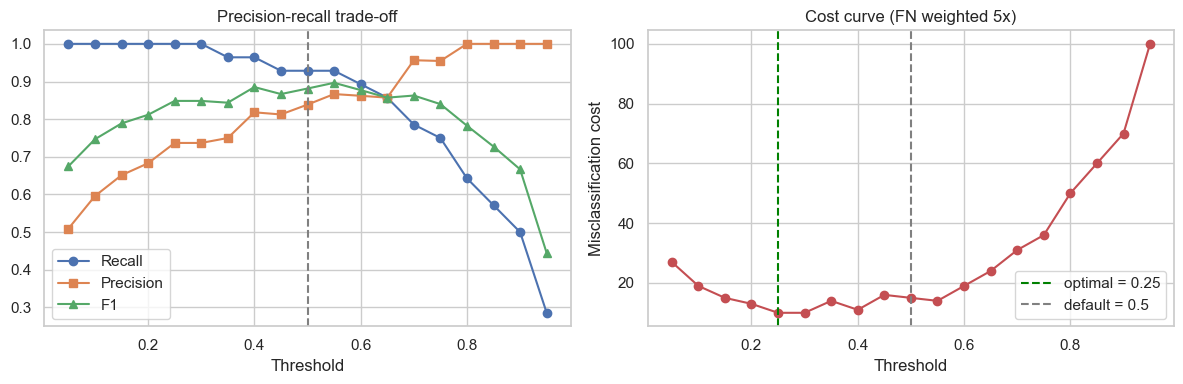

threshold            0.250000
Accuracy             0.836066
Precision            0.736842
Recall               1.000000
F1                   0.848485
FN                   0.000000
FP                  10.000000
Cost (5*FN + FP)    10.000000


In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(sweep["threshold"], sweep["Recall"], "o-", label="Recall")
ax[0].plot(sweep["threshold"], sweep["Precision"], "s-", label="Precision")
ax[0].plot(sweep["threshold"], sweep["F1"], "^-", label="F1")
ax[0].axvline(0.5, ls="--", c="grey"); ax[0].set_xlabel("Threshold")
ax[0].set_title("Precision-recall trade-off"); ax[0].legend()

best_i = sweep["Cost (5*FN + FP)"].idxmin()
ax[1].plot(sweep["threshold"], sweep["Cost (5*FN + FP)"], "o-", c="#c44e52")
ax[1].axvline(sweep.loc[best_i, "threshold"], ls="--", c="green",
              label=f"optimal = {sweep.loc[best_i,'threshold']}")
ax[1].axvline(0.5, ls="--", c="grey", label="default = 0.5")
ax[1].set_xlabel("Threshold"); ax[1].set_ylabel("Misclassification cost")
ax[1].set_title("Cost curve (FN weighted 5x)"); ax[1].legend()
plt.tight_layout(); plt.show()

print(sweep.loc[best_i].to_string())

In [16]:
# How sensitive is the recommendation to the 5:1 cost ratio we assumed?
print("FN:FP ratio -> cost-optimal threshold")
for ratio in [1, 2, 3, 5, 10, 20]:
    cost = ratio * sweep["FN"] + sweep["FP"]
    print(f"  {ratio:>2}:1  ->  {sweep.loc[cost.idxmin(), 'threshold']:.2f}")

FN:FP ratio -> cost-optimal threshold
   1:1  ->  0.55
   2:1  ->  0.40
   3:1  ->  0.40
   5:1  ->  0.25
  10:1  ->  0.25
  20:1  ->  0.25


**Moving the threshold from 0.50 to 0.25 eliminates both false negatives.** Recall
goes from 0.929 to **1.000** — every disease case in the test set is caught — at the
cost of 10 false positives instead of 5. Total cost falls from 15 to 10.

The sensitivity check matters, and it is more nuanced than a single number. Only a
1:1 ratio — treating a missed diagnosis as no worse than an unnecessary follow-up —
keeps the optimum near the 0.5 default (it selects 0.55). At 2:1 and 3:1 the optimum
moves to 0.40, and from 5:1 upward it settles at 0.25 and stays there.

So the *direction* is robust: any cost asymmetry at all pushes the threshold below
the default. The specific value 0.25 does depend on assuming a ratio of at least
5:1, which is a clinical judgement this project is not positioned to settle. What
can be said without qualification is that **0.5 is defensible only under a 1:1
assumption that every report in this project has explicitly rejected.**

**Recommendation: deploy Model B at a threshold of 0.25**, and route the 0.2–0.8
uncertainty band to clinician review. These are the two concrete reliability
improvements this week produced.

---
## 7. Calibration check

A threshold is only meaningful if the probabilities behind it mean something. This
checks whether a predicted 0.3 corresponds to roughly a 30% observed disease rate,
and whether the Platt scaling added in Week 5 helped.

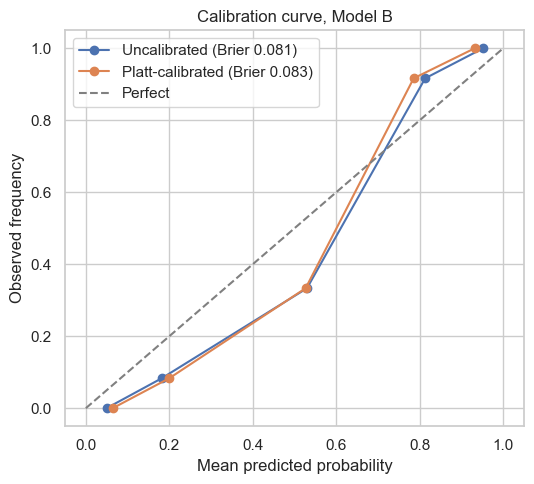

In [17]:
model_B_cal = CalibratedClassifierCV(model_B, method="sigmoid", cv=cv)
model_B_cal.fit(X_train, y_train)
proba_cal = model_B_cal.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(5.5, 5))
for proba, label in [(proba_B, "Uncalibrated"), (proba_cal, "Platt-calibrated")]:
    frac, mean_pred = calibration_curve(y_test, proba, n_bins=5, strategy="quantile")
    ax.plot(mean_pred, frac, "o-", label=f"{label} (Brier {brier_score_loss(y_test, proba):.3f})")
ax.plot([0, 1], [0, 1], "--", c="grey", label="Perfect")
ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Observed frequency")
ax.set_title("Calibration curve, Model B"); ax.legend()
plt.tight_layout(); plt.show()

Both curves track the diagonal closely and the Brier scores are effectively
identical (0.081 vs 0.083). **Calibration did not improve anything measurably** — a
regularized logistic regression is already close to well calibrated, so Platt scaling
has little left to correct, and on 61 test patients the small difference is noise.

This is reported as a negative result rather than quietly dropped. It is still worth
keeping in the served model because it costs nothing and protects against
miscalibration on future data, but the Week 5 report should not claim calibration as
an improvement.

---
## 8. MLflow experiment tracking

Every model and the threshold decision are logged to a local MLflow store, so the
runs are inspectable and comparable after the fact rather than living only in this
notebook's output.

In [18]:
mlflow.end_run()   # ensure a clean slate if this cell is re-run

for name, model in MODELS.items():
    with mlflow.start_run(run_name=name):
        params = {"model_family": type(model.named_steps.get("clf", model)).__name__,
                  "random_state": RANDOM_STATE, "cv_repeats": 10, "cv_folds": 5}
        if name.startswith("B"): params.update(grid_B.best_params_)
        if name.startswith("C"): params.update(grid_C.best_params_)
        mlflow.log_params(params)

        mlflow.log_metrics({k.replace("-", "_").lower(): v
                            for k, v in evaluate(model, X_test, y_test).items()})
        s = cv_scores[name]
        mlflow.log_metrics({"cv_roc_auc_mean": s.mean(), "cv_roc_auc_std": s.std(),
                            "cv_roc_auc_p2_5": np.percentile(s, 2.5),
                            "cv_roc_auc_p97_5": np.percentile(s, 97.5)})
        mlflow.set_tag("week", "6")

with mlflow.start_run(run_name="B threshold sweep"):
    mlflow.log_param("cost_ratio_FN_to_FP", 5)
    for _, r in sweep.iterrows():
        mlflow.log_metrics({"recall": r["Recall"], "precision": r["Precision"],
                            "cost": r["Cost (5*FN + FP)"]},
                           step=int(r["threshold"] * 100))
    mlflow.log_metrics({"optimal_threshold": sweep.loc[best_i, "threshold"],
                        "optimal_cost": sweep.loc[best_i, "Cost (5*FN + FP)"],
                        "recall_at_optimal": sweep.loc[best_i, "Recall"]})
    mlflow.set_tag("week", "6")

runs = mlflow.search_runs(experiment_names=["week6-heart-disease-testing"])
print(f"Logged {len(runs)} runs to mlflow.db")
runs[["tags.mlflow.runName", "metrics.roc_auc", "metrics.cv_roc_auc_mean", "metrics.recall"]]

Logged 4 runs to mlflow.db


,tags.mlflow.runName,metrics.roc_auc,metrics.cv_roc_auc_mean,metrics.recall
0,B threshold sweep,NaN,NaN,0.285714
1,C. Tuned Gradient Boosting,0.953463,0.895595,0.928571
2,B. Tuned LR + feature eng.,0.967532,0.915728,0.928571
3,A. Baseline LR (Week 3),0.951299,0.903035,0.928571


---
## 9. Summary of findings

| # | Finding | Evidence |
|---|---|---|
| 1 | Week 4's results are fully reproducible | §2, identical metrics and hyperparameters |
| 2 | **Model C's accuracy advantage was one patient and is not significant** | §4a, McNemar *p* = 1.00, 2 discordant pairs |
| 3 | Model B genuinely beats C across 50 folds | §4b, +0.020 ROC-AUC, corrected *p* = 0.014 |
| 4 | Errors occur only in the 0.2–0.8 probability band | §5a, 0 errors in 38 confident predictions |
| 5 | 6 of 7 errors are male patients | §5b, error rate 0.146 male vs 0.050 female |
| 6 | Both false negatives sit just under the threshold | §5c, probabilities 0.303 and 0.421 |
| 7 | **Threshold 0.25 removes all false negatives**, recall 1.000 | §6, cost 15 → 10; any cost asymmetry moves the threshold below 0.5 |
| 8 | Calibration produced no measurable gain | §7, Brier 0.081 → 0.083 |

## 10. Best practices adopted

1. **Compare models with paired significance tests, not metric tables.** A 1.7-point
   accuracy gap on 61 patients is one patient.
2. **Correct for fold overlap.** The naive paired t-test gave *p* < 1e-7 where the
   corrected test gave 0.014.
3. **Repeat cross-validation.** A single 5-fold run on 303 records is too noisy to
   select a model.
4. **Choose the threshold from an explicit cost, and check its sensitivity.** 0.5 is a
   library default, not a clinical decision.
5. **Report negative results.** Calibration did not help; that is documented, not
   dropped.
6. **Pin seeds and versions, and track runs.** Every number here is reproducible and
   logged to MLflow.

## 11. Limitations

The test set is 61 patients, so every subgroup estimate is wide and the threshold
recommendation is tuned on the same small sample it is evaluated on — the honest fix
is a proper validation split or nested CV for threshold selection, which 303 records
cannot really support. Aggregating the Hungarian, Switzerland, and VA cohorts remains
the highest-value next step. **Educational use only; not medical advice.**